# 22c - Confronto MaxViT: From-Scratch SD-VAE vs Fine-Tuned SD2.1

Questo notebook confronta i risultati salvati dai due esperimenti:

- **22a**: `Real + Augmented + Synthetic FromScratch_SD_VAE`
- **22b**: `Real + Augmented + Synthetic FineTuned_SD2.1`

Il notebook **non rifà il training**: legge i file prodotti da 22a e 22b (`val_metrics.json`, `test_metrics_maxvit512.json`, `bootstrap_balanced_test.json`, log CSV e figure) e genera tabelle/grafici di confronto in una cartella dedicata.

Da eseguire dopo aver completato entrambi i notebook 22a e 22b.

In [1]:
# === Bootstrap unificato notebooks/ ===
# Funziona dalla root del progetto e da ogni sottocartella della struttura notebooks/.
import sys as _sys
from pathlib import Path as _Path


def _find_mammo_root():
    for _candidate in [_Path.cwd().resolve(), *_Path.cwd().resolve().parents]:
        if _candidate.name == "MammoDiffusion":
            return _candidate
        if (_candidate / "data").is_dir() and (_candidate / "notebooks").is_dir():
            return _candidate
    raise FileNotFoundError("Root MammoDiffusion non trovata da " + str(_Path.cwd()))


PROJECT_ROOT = _find_mammo_root()
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
UTILITY_DIR = NOTEBOOKS_DIR / "utility"
for _path in (str(UTILITY_DIR), str(NOTEBOOKS_DIR)):
    if _path not in _sys.path:
        _sys.path.insert(0, _path)

BASE = PROJECT_ROOT
BASE_DIR = PROJECT_ROOT
BASE_PATH = str(PROJECT_ROOT) + "/"
# === Fine bootstrap unificato ===

import os
import sys
import json
from pathlib import Path
from datetime import date

COMPARE_DIR = (Path(BASE) / 'results' / 'classifiers' / 'maxvit512' / '02z_compare_fromscratch_vs_finetuned')
FIGURES_DIR = COMPARE_DIR / 'figures'
COMPARE_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print('Output confronto:', COMPARE_DIR)
print('Figure confronto:', FIGURES_DIR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

# Rilevamento robusto della root del progetto.
# Funziona sia se il notebook viene eseguito da /notebooks sia dalla root del progetto.
# [notebooks bootstrap] Il blocco Colab/local originale e' stato
# neutralizzato: BASE_PATH e BASE sono gia' definiti dal bootstrap
# unificato in cima al notebook.
print('Nota: questo notebook usa solo CPU/lettura file; non occupa VRAM in modo significativo.')

Percorso base: /home/fede/Documenti/MammoDiffusion
Output confronto: /home/fede/Documenti/MammoDiffusion/experiments/compare_22c_fromscratch_sdvae_vs_finetuned_sd21
Nota: questo notebook usa solo CPU/lettura file; non occupa VRAM in modo significativo.


## 1. Esperimenti confrontati

Se hai cambiato `FINE_TUNE_MODE` da `partial` a `full` nei notebook 22a/22b, modifica qui i nomi delle cartelle degli esperimenti.

In [2]:
FINE_TUNE_MODE = 'partial'

EXPERIMENTS = {
    'FromScratch_SD_VAE': {
        'label': 'From-Scratch SD-VAE',
        'notebook': '22a_Classificatore_RealAugmentedSyntheticFromScratchSDVAE_MaxViT512_FineTuned.ipynb',
        'synthetic_source': 'data/synthetic/fromscratch_new',
        'experiment_dir': BASE / 'experiments' / f'classifiers/maxvit512/02i_real_aug_synth_fromscratch_{FINE_TUNE_MODE}',
        'train_csv': BASE / 'data' / 'synthetic' / 'metadata' / 'train_real_augmented_synthetic_fromscratch_sdvae.csv',
    },
    'FineTuned_SD2.1': {
        'label': 'Fine-Tuned SD2.1',
        'notebook': '22b_Classificatore_RealAugmentedSyntheticFineTunedSD_MaxViT512_FineTuned.ipynb',
        'synthetic_source': 'data/synthetic/fine_tuned',
        'experiment_dir': BASE / 'experiments' / f'classifiers/maxvit512/02j_real_aug_synth_finetuned_{FINE_TUNE_MODE}',
        'train_csv': BASE / 'data' / 'synthetic' / 'metadata' / 'train_real_augmented_synthetic_finetuned_sd21.csv',
    },
}

rows = []
for key, cfg in EXPERIMENTS.items():
    rows.append({
        'id': key,
        'label': cfg['label'],
        'experiment_dir': str(cfg['experiment_dir']),
        'experiment_dir_exists': cfg['experiment_dir'].exists(),
        'train_csv': str(cfg['train_csv']),
        'train_csv_exists': cfg['train_csv'].exists(),
    })

display(pd.DataFrame(rows))

,id,label,experiment_dir,experiment_dir_exists,train_csv,train_csv_exists
0,FromScratch_SD_VAE,From-Scratch SD-VAE,/home/fede/Documenti/MammoDiffusion/experiment...,True,/home/fede/Documenti/MammoDiffusion/data/synth...,True
1,FineTuned_SD2.1,Fine-Tuned SD2.1,/home/fede/Documenti/MammoDiffusion/experiment...,True,/home/fede/Documenti/MammoDiffusion/data/synth...,True


## 2. Funzioni di lettura e normalizzazione

Queste funzioni leggono i JSON/CSV salvati dai notebook 22a e 22b e li trasformano in tabelle confrontabili.

In [3]:
METRIC_KEYS = [
    'roc_auc',
    'accuracy',
    'precision_malato',
    'recall_malato',
    'f1_malato',
]

PHASE_FILES = {
    'fase1_head': 'training_log_fase1.csv',
    'fase2_finetune': 'training_log_fase2.csv',
}

REQUIRED_FILES = [
    'val_metrics.json',
    'test_metrics_maxvit512.json',
    'bootstrap_balanced_test.json',
    'experiment_config.json',
]


def read_json(path, required=False):
    path = Path(path)
    if not path.exists():
        if required:
            raise FileNotFoundError(f'File mancante: {path}')
        return None
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def as_float(value):
    if value is None:
        return np.nan
    try:
        return float(value)
    except Exception:
        return np.nan


def metric_record(metrics, experiment_key, cfg, split):
    metrics = metrics or {}
    row = {
        'experiment_key': experiment_key,
        'source_label': cfg['label'],
        'split': split,
        'config': metrics.get('config', None),
        'experiment_name': metrics.get('experiment_name', Path(cfg['experiment_dir']).name),
        'fine_tune_mode': metrics.get('fine_tune_mode', FINE_TUNE_MODE),
        'threshold_youden_from_val': as_float(
            metrics.get('threshold_youden_from_val', metrics.get('optimal_threshold_youden'))
        ),
        'checkpoint': metrics.get('checkpoint', None),
    }
    for key in METRIC_KEYS:
        row[key] = as_float(metrics.get(key))
    return row


def source_counts_from_config(config):
    data = (config or {}).get('data', {})
    counts = data.get('source_counts', {})
    rows = []
    for source_detail, values in counts.items():
        rows.append({
            'source_detail': source_detail,
            'sano_0': int(values.get('sano_0', values.get('0', 0)) or 0),
            'malato_1': int(values.get('malato_1', values.get('1', 0)) or 0),
            'totale': int(values.get('totale', 0) or 0),
        })
    return rows


def source_counts_from_csv(csv_path):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        return []
    df = pd.read_csv(csv_path)
    if not {'source_detail', 'cancer'}.issubset(df.columns):
        return []
    table = pd.crosstab(df['source_detail'], df['cancer']).rename(columns={0: 'sano_0', 1: 'malato_1'})
    if 'sano_0' not in table.columns:
        table['sano_0'] = 0
    if 'malato_1' not in table.columns:
        table['malato_1'] = 0
    table['totale'] = table[['sano_0', 'malato_1']].sum(axis=1)
    return table.reset_index().to_dict(orient='records')


def display_path_status(path):
    path = Path(path)
    return 'OK' if path.exists() else 'MANCANTE' 

## 3. Caricamento risultati

Se questa cella segnala file mancanti, significa che uno dei due notebook non è arrivato alla fine o che `FINE_TUNE_MODE` non corrisponde alla cartella corretta.

In [4]:
metrics_records = []
bootstrap_records = []
config_records = []
source_records = []
log_records = []
artifact_records = []
missing = []

for experiment_key, cfg in EXPERIMENTS.items():
    exp_dir = Path(cfg['experiment_dir'])

    for filename in REQUIRED_FILES:
        path = exp_dir / filename
        artifact_records.append({
            'experiment': cfg['label'],
            'artifact': filename,
            'path': str(path),
            'exists': path.exists(),
        })
        if not path.exists():
            missing.append(path)

    val_metrics = read_json(exp_dir / 'val_metrics.json')
    test_metrics = read_json(exp_dir / 'test_metrics_maxvit512.json')
    config = read_json(exp_dir / 'experiment_config.json')
    bootstrap = read_json(exp_dir / 'bootstrap_balanced_test.json')

    metrics_records.append(metric_record(val_metrics, experiment_key, cfg, 'validation'))
    metrics_records.append(metric_record(test_metrics, experiment_key, cfg, 'test'))

    data_cfg = (config or {}).get('data', {})
    config_records.append({
        'experiment_key': experiment_key,
        'source_label': cfg['label'],
        'experiment_name': (config or {}).get('experiment_name', exp_dir.name),
        'date': (config or {}).get('date', None),
        'fine_tune_mode': FINE_TUNE_MODE,
        'n_train': data_cfg.get('n_train', np.nan),
        'n_val': data_cfg.get('n_val', np.nan),
        'batch_size': data_cfg.get('batch_size', np.nan),
        'seed': data_cfg.get('seed', np.nan),
        'synthetic_source': cfg['synthetic_source'],
    })

    # Preferisco il CSV effettivo se esiste; altrimenti uso source_counts da experiment_config.
    counts_rows = source_counts_from_csv(cfg['train_csv']) or source_counts_from_config(config)
    for row in counts_rows:
        source_records.append({
            'experiment_key': experiment_key,
            'source_label': cfg['label'],
            **row,
        })

    if isinstance(bootstrap, dict):
        for metric_name, summary in bootstrap.items():
            if isinstance(summary, dict):
                bootstrap_records.append({
                    'experiment_key': experiment_key,
                    'source_label': cfg['label'],
                    'metric': metric_name,
                    'mean': as_float(summary.get('mean')),
                    'std': as_float(summary.get('std')),
                })

    for phase, filename in PHASE_FILES.items():
        path = exp_dir / filename
        if path.exists():
            log = pd.read_csv(path)
            log['experiment_key'] = experiment_key
            log['source_label'] = cfg['label']
            log['phase'] = phase
            log['phase_file'] = filename
            log['phase_epoch'] = np.arange(1, len(log) + 1)
            log_records.append(log)

artifact_df = pd.DataFrame(artifact_records)
metrics_df = pd.DataFrame(metrics_records)
config_df = pd.DataFrame(config_records)
source_counts_df = pd.DataFrame(source_records)
bootstrap_df = pd.DataFrame(bootstrap_records)
training_logs_df = pd.concat(log_records, ignore_index=True) if log_records else pd.DataFrame()

print('Stato artifact:')
display(artifact_df)

if missing:
    print()
    print('File mancanti:')
    for path in missing:
        print('-', path)
    raise FileNotFoundError(
        'Mancano alcuni file prodotti dai notebook 22a/22b. '
        'Esegui prima entrambi i notebook fino alla fine oppure correggi FINE_TUNE_MODE/percorsi.'
    )

print('Metriche caricate:')
display(metrics_df)

# Salvataggio tabelle grezze del confronto
metrics_df.to_csv(COMPARE_DIR / 'metrics_22c_long.csv', index=False)
config_df.to_csv(COMPARE_DIR / 'experiment_config_22c_summary.csv', index=False)
source_counts_df.to_csv(COMPARE_DIR / 'source_counts_22c.csv', index=False)
if not bootstrap_df.empty:
    bootstrap_df.to_csv(COMPARE_DIR / 'bootstrap_22c_long.csv', index=False)
if not training_logs_df.empty:
    training_logs_df.to_csv(COMPARE_DIR / 'training_logs_22c_long.csv', index=False)

print('Tabelle salvate in:', COMPARE_DIR)

Stato artifact:


,experiment,artifact,path,exists
0,From-Scratch SD-VAE,val_metrics.json,/home/fede/Documenti/MammoDiffusion/experiment...,True
1,From-Scratch SD-VAE,test_metrics_maxvit512.json,/home/fede/Documenti/MammoDiffusion/experiment...,True
2,From-Scratch SD-VAE,bootstrap_balanced_test.json,/home/fede/Documenti/MammoDiffusion/experiment...,True
3,From-Scratch SD-VAE,experiment_config.json,/home/fede/Documenti/MammoDiffusion/experiment...,True
4,Fine-Tuned SD2.1,val_metrics.json,/home/fede/Documenti/MammoDiffusion/experiment...,True
5,Fine-Tuned SD2.1,test_metrics_maxvit512.json,/home/fede/Documenti/MammoDiffusion/experiment...,True
6,Fine-Tuned SD2.1,bootstrap_balanced_test.json,/home/fede/Documenti/MammoDiffusion/experiment...,True
7,Fine-Tuned SD2.1,experiment_config.json,/home/fede/Documenti/MammoDiffusion/experiment...,True


Metriche caricate:


,experiment_key,source_label,split,config,experiment_name,fine_tune_mode,threshold_youden_from_val,checkpoint,roc_auc,accuracy,precision_malato,recall_malato,f1_malato
0,FromScratch_SD_VAE,From-Scratch SD-VAE,validation,Real+Augmented+FromScratch_SD_VAE,exp_maxvit512_real_aug_synth_fromscratch_sdvae...,partial,0.4215,/home/fede/Documenti/MammoDiffusion/experiment...,0.6117,0.6522,0.2452,0.5205,0.3333
1,FromScratch_SD_VAE,From-Scratch SD-VAE,test,Real+Augmented+FromScratch_SD_VAE,exp_maxvit512_real_aug_synth_fromscratch_sdvae...,partial,0.4215,/home/fede/Documenti/MammoDiffusion/experiment...,0.5938,0.6233,0.2051,0.4384,0.2795
2,FineTuned_SD2.1,Fine-Tuned SD2.1,validation,Real+Augmented+FineTuned_SD2.1,exp_maxvit512_real_aug_synth_finetuned_sd21_pa...,partial,0.4025,/home/fede/Documenti/MammoDiffusion/experiment...,0.6236,0.6224,0.2473,0.6164,0.3529
3,FineTuned_SD2.1,Fine-Tuned SD2.1,test,Real+Augmented+FineTuned_SD2.1,exp_maxvit512_real_aug_synth_finetuned_sd21_pa...,partial,0.4025,/home/fede/Documenti/MammoDiffusion/experiment...,0.6173,0.5845,0.2176,0.5753,0.3158


Tabelle salvate in: /home/fede/Documenti/MammoDiffusion/experiments/compare_22c_fromscratch_sdvae_vs_finetuned_sd21


## 4. Composizione dei training set

Qui verifico che il confronto sia equo in termini di split reali e numero di immagini sintetiche/augmentate.

In [5]:
display(Markdown('### Configurazione generale'))
display(config_df)

if not source_counts_df.empty:
    display(Markdown('### Conteggi per sorgente e classe'))
    display(source_counts_df.sort_values(['source_label', 'source_detail']))

    pivot_counts = source_counts_df.pivot_table(
        index='source_detail',
        columns='source_label',
        values=['sano_0', 'malato_1', 'totale'],
        aggfunc='sum',
        fill_value=0,
    )
    display(Markdown('### Tabella pivot conteggi'))
    display(pivot_counts)
else:
    print('Nessuna tabella conteggi disponibile.')

### Configurazione generale

,experiment_key,source_label,experiment_name,date,fine_tune_mode,n_train,n_val,batch_size,seed,synthetic_source
0,FromScratch_SD_VAE,From-Scratch SD-VAE,exp_maxvit512_real_aug_synth_fromscratch_sdvae...,2026-07-05,partial,5783,437,8,42,data/synthetic/fromscratch_new
1,FineTuned_SD2.1,Fine-Tuned SD2.1,exp_maxvit512_real_aug_synth_finetuned_sd21_pa...,2026-07-05,partial,5783,437,8,42,data/synthetic/fine_tuned


### Conteggi per sorgente e classe

,experiment_key,source_label,source_detail,sano_0,malato_1,totale
3,FineTuned_SD2.1,Fine-Tuned SD2.1,FineTuned_SD2.1,1361,1361,2722
4,FineTuned_SD2.1,Fine-Tuned SD2.1,real_train,1701,340,2041
5,FineTuned_SD2.1,Fine-Tuned SD2.1,traditional_positive_augmentation,0,1020,1020
0,FromScratch_SD_VAE,From-Scratch SD-VAE,FromScratch_SD_VAE,1361,1361,2722
1,FromScratch_SD_VAE,From-Scratch SD-VAE,real_train,1701,340,2041
2,FromScratch_SD_VAE,From-Scratch SD-VAE,traditional_positive_augmentation,0,1020,1020


### Tabella pivot conteggi

malato_1                               sano_0                               totale                    
source_label                      Fine-Tuned SD2.1 From-Scratch SD-VAE Fine-Tuned SD2.1 From-Scratch SD-VAE Fine-Tuned SD2.1 From-Scratch SD-VAE
source_detail                                                                                                                                   
FineTuned_SD2.1                               1361                   0             1361                   0             2722                   0
FromScratch_SD_VAE                               0                1361                0                1361                0                2722
real_train                                     340                 340             1701                1701             2041                2041
traditional_positive_augmentation             1020                1020                0                   0             1020                1020

## 5. Tabella principale validation/test

Le metriche usano la soglia di Youden stimata sulla validation e poi applicata al test.

In [6]:
ordered_labels = [cfg['label'] for cfg in EXPERIMENTS.values()]

summary_table = metrics_df[[
    'source_label', 'split', 'roc_auc', 'accuracy', 'precision_malato',
    'recall_malato', 'f1_malato', 'threshold_youden_from_val', 'checkpoint'
]].copy()
summary_table['source_label'] = pd.Categorical(summary_table['source_label'], categories=ordered_labels, ordered=True)
summary_table = summary_table.sort_values(['split', 'source_label'])

display(summary_table)
summary_table.to_csv(COMPARE_DIR / 'summary_validation_test_22c.csv', index=False)

# Versione wide, utile per lettura e scrittura relazione.
wide_rows = []
for split in ['validation', 'test']:
    split_df = metrics_df[metrics_df['split'] == split].set_index('source_label')
    row = {'split': split}
    for metric in METRIC_KEYS:
        for label in ordered_labels:
            row[f'{metric}__{label}'] = split_df.loc[label, metric] if label in split_df.index else np.nan
        if all(label in split_df.index for label in ordered_labels):
            row[f'delta_{metric}__FineTuned_minus_FromScratch'] = split_df.loc['Fine-Tuned SD2.1', metric] - split_df.loc['From-Scratch SD-VAE', metric]
    wide_rows.append(row)

wide_comparison_df = pd.DataFrame(wide_rows)
display(Markdown('### Differenze Fine-Tuned SD2.1 - From-Scratch SD-VAE'))
display(wide_comparison_df)
wide_comparison_df.to_csv(COMPARE_DIR / 'wide_comparison_22c.csv', index=False)

,source_label,split,roc_auc,accuracy,precision_malato,recall_malato,f1_malato,threshold_youden_from_val,checkpoint
1,From-Scratch SD-VAE,test,0.5938,0.6233,0.2051,0.4384,0.2795,0.4215,/home/fede/Documenti/MammoDiffusion/experiment...
3,Fine-Tuned SD2.1,test,0.6173,0.5845,0.2176,0.5753,0.3158,0.4025,/home/fede/Documenti/MammoDiffusion/experiment...
0,From-Scratch SD-VAE,validation,0.6117,0.6522,0.2452,0.5205,0.3333,0.4215,/home/fede/Documenti/MammoDiffusion/experiment...
2,Fine-Tuned SD2.1,validation,0.6236,0.6224,0.2473,0.6164,0.3529,0.4025,/home/fede/Documenti/MammoDiffusion/experiment...


### Differenze Fine-Tuned SD2.1 - From-Scratch SD-VAE

,split,roc_auc__From-Scratch SD-VAE,roc_auc__Fine-Tuned SD2.1,delta_roc_auc__FineTuned_minus_FromScratch,accuracy__From-Scratch SD-VAE,accuracy__Fine-Tuned SD2.1,delta_accuracy__FineTuned_minus_FromScratch,precision_malato__From-Scratch SD-VAE,precision_malato__Fine-Tuned SD2.1,delta_precision_malato__FineTuned_minus_FromScratch,recall_malato__From-Scratch SD-VAE,recall_malato__Fine-Tuned SD2.1,delta_recall_malato__FineTuned_minus_FromScratch,f1_malato__From-Scratch SD-VAE,f1_malato__Fine-Tuned SD2.1,delta_f1_malato__FineTuned_minus_FromScratch
0,validation,0.6117,0.6236,0.0119,0.6522,0.6224,-0.0298,0.2452,0.2473,0.0021,0.5205,0.6164,0.0959,0.3333,0.3529,0.0196
1,test,0.5938,0.6173,0.0235,0.6233,0.5845,-0.0388,0.2051,0.2176,0.0125,0.4384,0.5753,0.1369,0.2795,0.3158,0.0363


## 6. Grafico metriche principali su validation e test

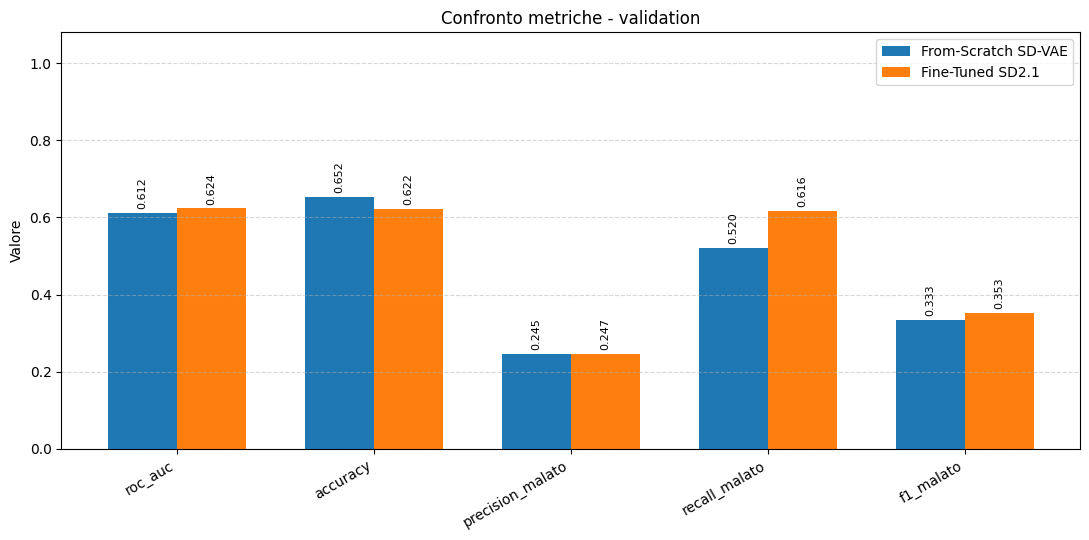

Grafico salvato in: /home/fede/Documenti/MammoDiffusion/experiments/compare_22c_fromscratch_sdvae_vs_finetuned_sd21/figures/metrics_validation_22c.png


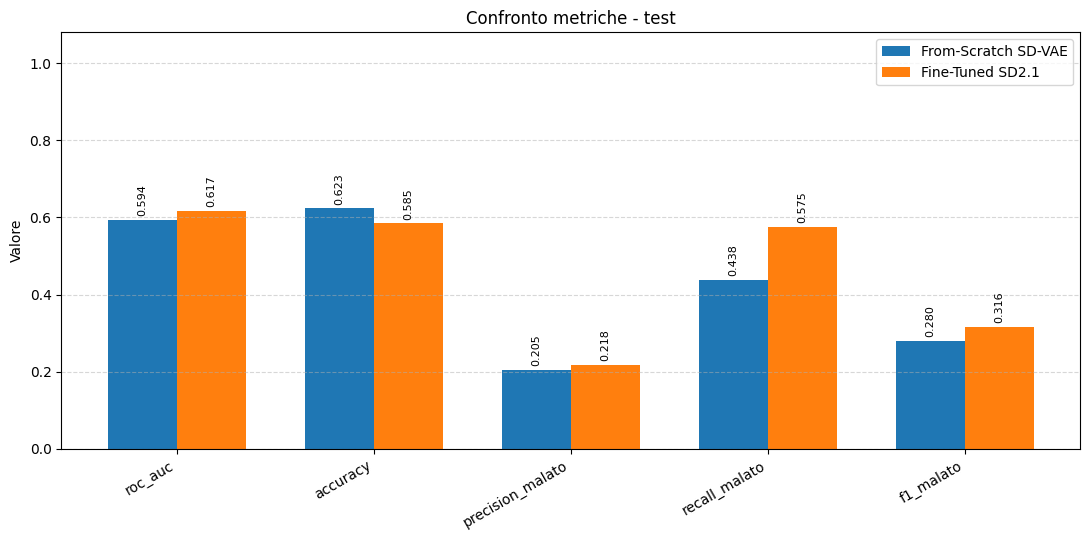

Grafico salvato in: /home/fede/Documenti/MammoDiffusion/experiments/compare_22c_fromscratch_sdvae_vs_finetuned_sd21/figures/metrics_test_22c.png


In [7]:
def plot_split_metrics(metrics_df, split, save_path):
    plot_df = metrics_df[metrics_df['split'] == split].copy()
    plot_df['source_label'] = pd.Categorical(plot_df['source_label'], categories=ordered_labels, ordered=True)
    plot_df = plot_df.sort_values('source_label')
    if plot_df.empty:
        print(f'Nessun dato per split={split}')
        return

    x = np.arange(len(METRIC_KEYS))
    width = 0.35
    fig, ax = plt.subplots(figsize=(11, 5.5))

    for i, label in enumerate(ordered_labels):
        values = plot_df.loc[plot_df['source_label'] == label, METRIC_KEYS]
        if values.empty:
            continue
        values = values.iloc[0].astype(float).values
        offset = (i - (len(ordered_labels) - 1) / 2) * width
        bars = ax.bar(x + offset, values, width, label=label)
        for bar, value in zip(bars, values):
            if np.isfinite(value):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f'{value:.3f}',
                    ha='center',
                    va='bottom',
                    fontsize=8,
                    rotation=90,
                )

    ax.set_title(f'Confronto metriche - {split}')
    ax.set_ylabel('Valore')
    ax.set_ylim(0, 1.08)
    ax.set_xticks(x)
    ax.set_xticklabels(METRIC_KEYS, rotation=30, ha='right')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Grafico salvato in:', save_path)

plot_split_metrics(metrics_df, 'validation', FIGURES_DIR / 'metrics_validation_22c.png')
plot_split_metrics(metrics_df, 'test', FIGURES_DIR / 'metrics_test_22c.png')

## 7. Delta delle metriche sul test

Valori positivi indicano vantaggio di **Fine-Tuned SD2.1** rispetto a **From-Scratch SD-VAE**.

,metric,fromscratch_sdvae,finetuned_sd21,delta_finetuned_minus_fromscratch,winner
0,roc_auc,0.5938,0.6173,0.0235,Fine-Tuned SD2.1
1,accuracy,0.6233,0.5845,-0.0388,From-Scratch SD-VAE
2,precision_malato,0.2051,0.2176,0.0125,Fine-Tuned SD2.1
3,recall_malato,0.4384,0.5753,0.1369,Fine-Tuned SD2.1
4,f1_malato,0.2795,0.3158,0.0363,Fine-Tuned SD2.1


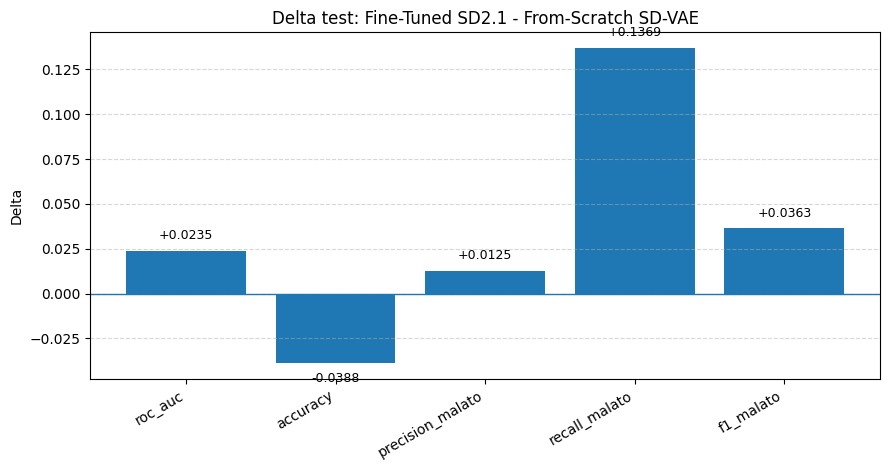

In [8]:
test_df = metrics_df[metrics_df['split'] == 'test'].set_index('source_label')
if all(label in test_df.index for label in ordered_labels):
    delta_test = pd.DataFrame({
        'metric': METRIC_KEYS,
        'fromscratch_sdvae': [test_df.loc['From-Scratch SD-VAE', m] for m in METRIC_KEYS],
        'finetuned_sd21': [test_df.loc['Fine-Tuned SD2.1', m] for m in METRIC_KEYS],
    })
    delta_test['delta_finetuned_minus_fromscratch'] = delta_test['finetuned_sd21'] - delta_test['fromscratch_sdvae']
    delta_test['winner'] = np.where(
        delta_test['delta_finetuned_minus_fromscratch'] > 0,
        'Fine-Tuned SD2.1',
        np.where(delta_test['delta_finetuned_minus_fromscratch'] < 0, 'From-Scratch SD-VAE', 'pareggio')
    )
    display(delta_test)
    delta_test.to_csv(COMPARE_DIR / 'delta_test_22c.csv', index=False)

    fig, ax = plt.subplots(figsize=(9, 4.8))
    bars = ax.bar(delta_test['metric'], delta_test['delta_finetuned_minus_fromscratch'])
    ax.axhline(0, linewidth=1)
    ax.set_title('Delta test: Fine-Tuned SD2.1 - From-Scratch SD-VAE')
    ax.set_ylabel('Delta')
    ax.set_xticks(np.arange(len(delta_test)))
    ax.set_xticklabels(delta_test['metric'], rotation=30, ha='right')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    for bar, value in zip(bars, delta_test['delta_finetuned_minus_fromscratch']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + (0.005 if value >= 0 else -0.005),
            f'{value:+.4f}',
            ha='center',
            va='bottom' if value >= 0 else 'top',
            fontsize=9,
        )
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'delta_test_22c.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Impossibile calcolare delta test: manca uno dei due esperimenti.')

## 8. Bootstrap bilanciato sul test

Questa sezione confronta media e deviazione standard delle metriche bootstrap salvate dai notebook. È utile per capire se il vantaggio osservato è stabile o molto rumoroso.

,experiment_key,source_label,metric,mean,std
5,FineTuned_SD2.1,Fine-Tuned SD2.1,Accuracy,0.580466,0.038212
0,FromScratch_SD_VAE,From-Scratch SD-VAE,Accuracy,0.549479,0.038992
8,FineTuned_SD2.1,Fine-Tuned SD2.1,F1,0.578637,0.042143
3,FromScratch_SD_VAE,From-Scratch SD-VAE,F1,0.493473,0.048844
6,FineTuned_SD2.1,Fine-Tuned SD2.1,Precision,0.581458,0.039513
1,FromScratch_SD_VAE,From-Scratch SD-VAE,Precision,0.563980,0.050345
9,FineTuned_SD2.1,Fine-Tuned SD2.1,ROC_AUC,0.617487,0.044351
4,FromScratch_SD_VAE,From-Scratch SD-VAE,ROC_AUC,0.593721,0.045902
7,FineTuned_SD2.1,Fine-Tuned SD2.1,Recall,0.577767,0.055515
2,FromScratch_SD_VAE,From-Scratch SD-VAE,Recall,0.440616,0.055040


### Bootstrap pivot

mean                                  std                    
source_label Fine-Tuned SD2.1 From-Scratch SD-VAE Fine-Tuned SD2.1 From-Scratch SD-VAE
metric                                                                                
Accuracy             0.580466            0.549479         0.038212            0.038992
F1                   0.578637            0.493473         0.042143            0.048844
Precision            0.581458            0.563980         0.039513            0.050345
ROC_AUC              0.617487            0.593721         0.044351            0.045902
Recall               0.577767            0.440616         0.055515            0.055040

### Delta bootstrap approssimato

,metric,mean_fromscratch,std_fromscratch,mean_finetuned,std_finetuned,delta_mean_finetuned_minus_fromscratch,std_combined_approx,delta_over_std_combined
0,Accuracy,0.549479,0.038992,0.580466,0.038212,0.030986,0.054594,0.567578
1,F1,0.493473,0.048844,0.578637,0.042143,0.085164,0.064512,1.320131
2,Precision,0.563980,0.050345,0.581458,0.039513,0.017477,0.063999,0.273088
3,ROC_AUC,0.593721,0.045902,0.617487,0.044351,0.023766,0.063828,0.372347
4,Recall,0.440616,0.055040,0.577767,0.055515,0.137151,0.078175,1.754402


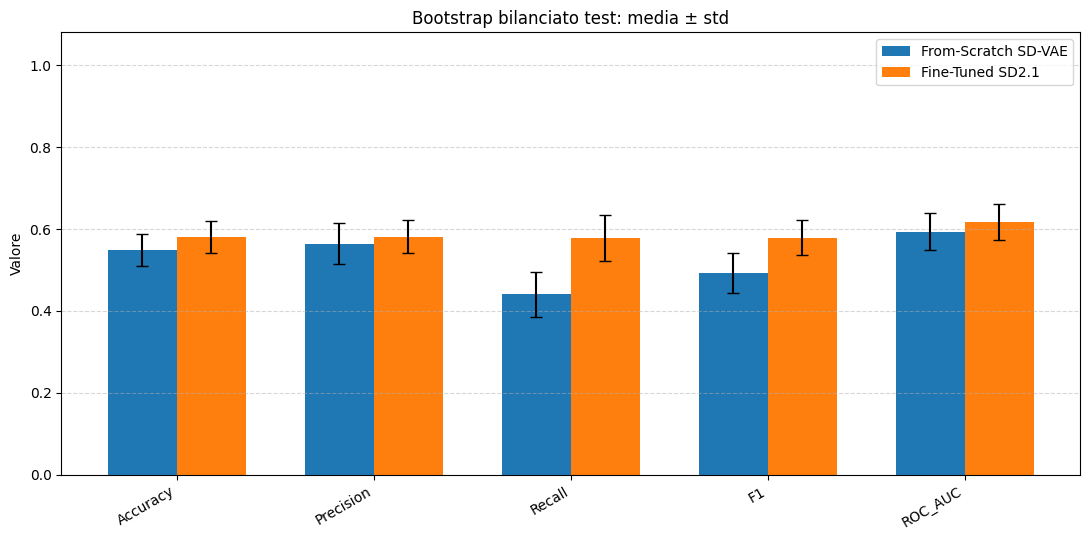

Grafico salvato in: /home/fede/Documenti/MammoDiffusion/experiments/compare_22c_fromscratch_sdvae_vs_finetuned_sd21/figures/bootstrap_mean_std_22c.png


In [9]:
if bootstrap_df.empty:
    print('Bootstrap non disponibile.')
else:
    display(bootstrap_df.sort_values(['metric', 'source_label']))

    bootstrap_pivot = bootstrap_df.pivot_table(
        index='metric',
        columns='source_label',
        values=['mean', 'std'],
        aggfunc='first',
    )
    display(Markdown('### Bootstrap pivot'))
    display(bootstrap_pivot)

    # Delta bootstrap approssimato: differenza delle medie e std combinata.
    boot_delta_rows = []
    for metric in sorted(bootstrap_df['metric'].dropna().unique()):
        sub = bootstrap_df[bootstrap_df['metric'] == metric].set_index('source_label')
        if all(label in sub.index for label in ordered_labels):
            mean_fs = sub.loc['From-Scratch SD-VAE', 'mean']
            std_fs = sub.loc['From-Scratch SD-VAE', 'std']
            mean_ft = sub.loc['Fine-Tuned SD2.1', 'mean']
            std_ft = sub.loc['Fine-Tuned SD2.1', 'std']
            delta = mean_ft - mean_fs
            std_combined = float(np.sqrt(std_fs ** 2 + std_ft ** 2)) if np.isfinite(std_fs) and np.isfinite(std_ft) else np.nan
            boot_delta_rows.append({
                'metric': metric,
                'mean_fromscratch': mean_fs,
                'std_fromscratch': std_fs,
                'mean_finetuned': mean_ft,
                'std_finetuned': std_ft,
                'delta_mean_finetuned_minus_fromscratch': delta,
                'std_combined_approx': std_combined,
                'delta_over_std_combined': delta / std_combined if std_combined and np.isfinite(std_combined) else np.nan,
            })
    boot_delta_df = pd.DataFrame(boot_delta_rows)
    display(Markdown('### Delta bootstrap approssimato'))
    display(boot_delta_df)
    boot_delta_df.to_csv(COMPARE_DIR / 'bootstrap_delta_22c.csv', index=False)

    metrics_to_plot = list(bootstrap_df['metric'].dropna().unique())
    x = np.arange(len(metrics_to_plot))
    width = 0.35
    fig, ax = plt.subplots(figsize=(11, 5.5))
    for i, label in enumerate(ordered_labels):
        sub = bootstrap_df[bootstrap_df['source_label'] == label].set_index('metric').reindex(metrics_to_plot)
        y = sub['mean'].astype(float).values
        yerr = sub['std'].astype(float).values
        offset = (i - (len(ordered_labels) - 1) / 2) * width
        ax.bar(x + offset, y, width, yerr=yerr, capsize=4, label=label)
    ax.set_title('Bootstrap bilanciato test: media ± std')
    ax.set_ylabel('Valore')
    ax.set_ylim(0, 1.08)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_to_plot, rotation=30, ha='right')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'bootstrap_mean_std_22c.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Grafico salvato in:', FIGURES_DIR / 'bootstrap_mean_std_22c.png')

## 9. Curve di training

Confronto delle curve salvate nei log `training_log_fase1.csv` e `training_log_fase2.csv`.

La fase 1 allena la testa; la fase 2 fa fine-tuning parziale/full secondo `FINE_TUNE_MODE`.

,epoch,loss,auc,val_loss,val_auc,experiment_key,source_label,phase,phase_file,phase_epoch
0,1,0.682261,0.687159,0.586683,0.519758,FromScratch_SD_VAE,From-Scratch SD-VAE,fase1_head,training_log_fase1.csv,1
1,2,0.606430,0.772418,0.589029,0.610530,FromScratch_SD_VAE,From-Scratch SD-VAE,fase1_head,training_log_fase1.csv,2
2,3,0.557134,0.813970,0.577477,0.576509,FromScratch_SD_VAE,From-Scratch SD-VAE,fase1_head,training_log_fase1.csv,3
3,4,0.499189,0.855695,0.570655,0.568305,FromScratch_SD_VAE,From-Scratch SD-VAE,fase1_head,training_log_fase1.csv,4
4,5,0.460320,0.879294,0.569939,0.578127,FromScratch_SD_VAE,From-Scratch SD-VAE,fase1_head,training_log_fase1.csv,5


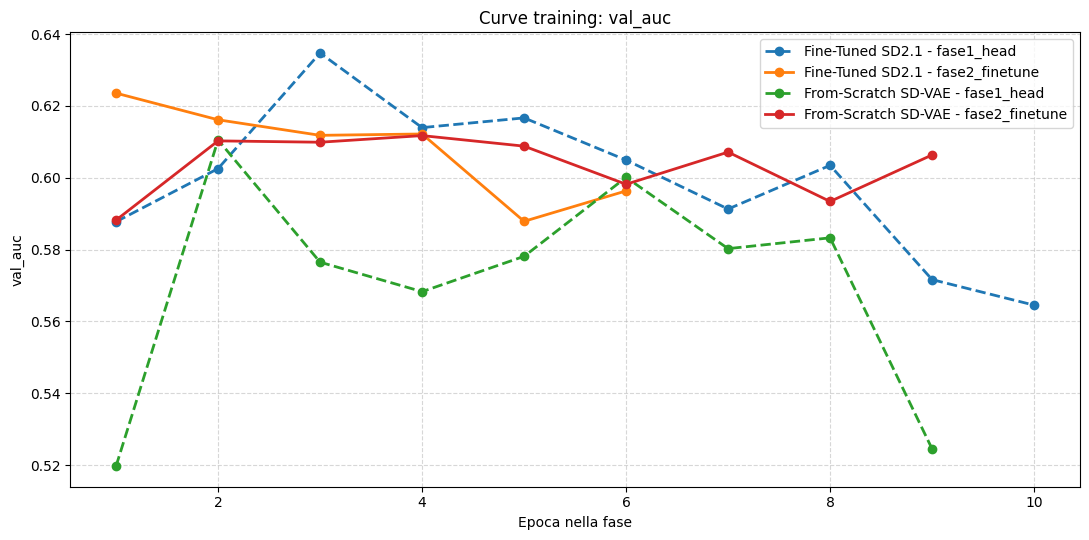

Grafico salvato in: /home/fede/Documenti/MammoDiffusion/experiments/compare_22c_fromscratch_sdvae_vs_finetuned_sd21/figures/training_val_auc_22c.png


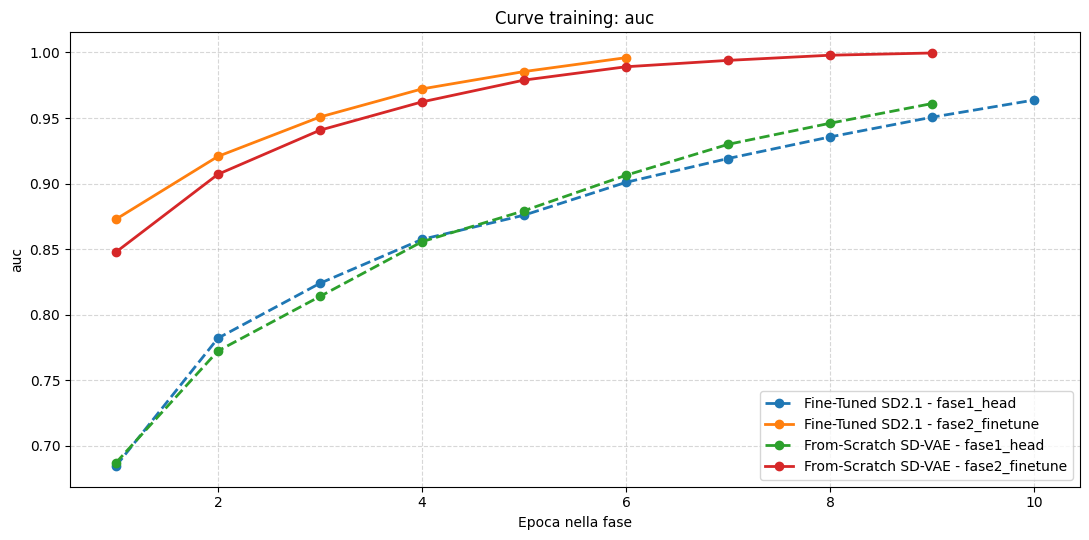

Grafico salvato in: /home/fede/Documenti/MammoDiffusion/experiments/compare_22c_fromscratch_sdvae_vs_finetuned_sd21/figures/training_auc_22c.png


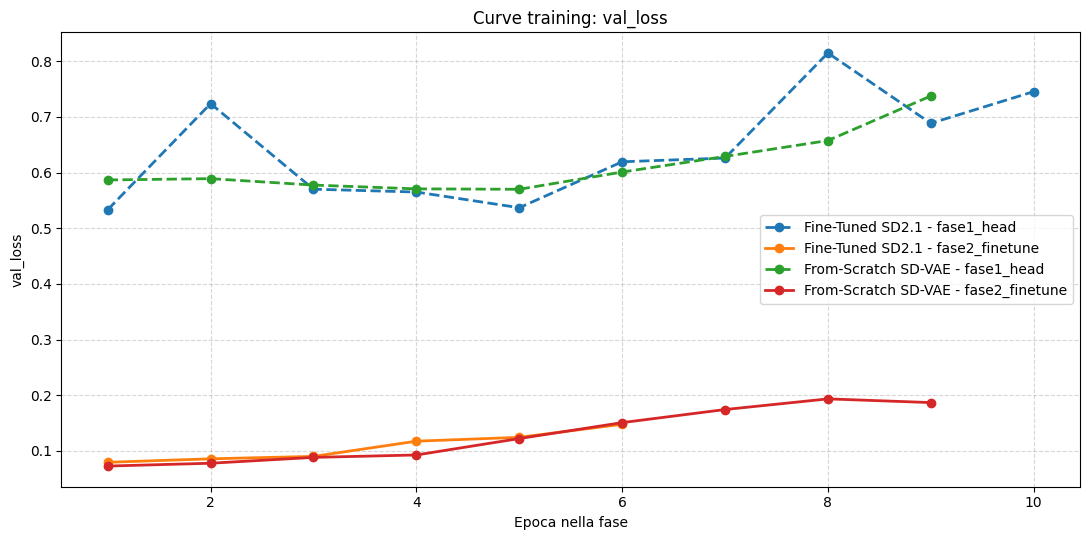

Grafico salvato in: /home/fede/Documenti/MammoDiffusion/experiments/compare_22c_fromscratch_sdvae_vs_finetuned_sd21/figures/training_val_loss_22c.png


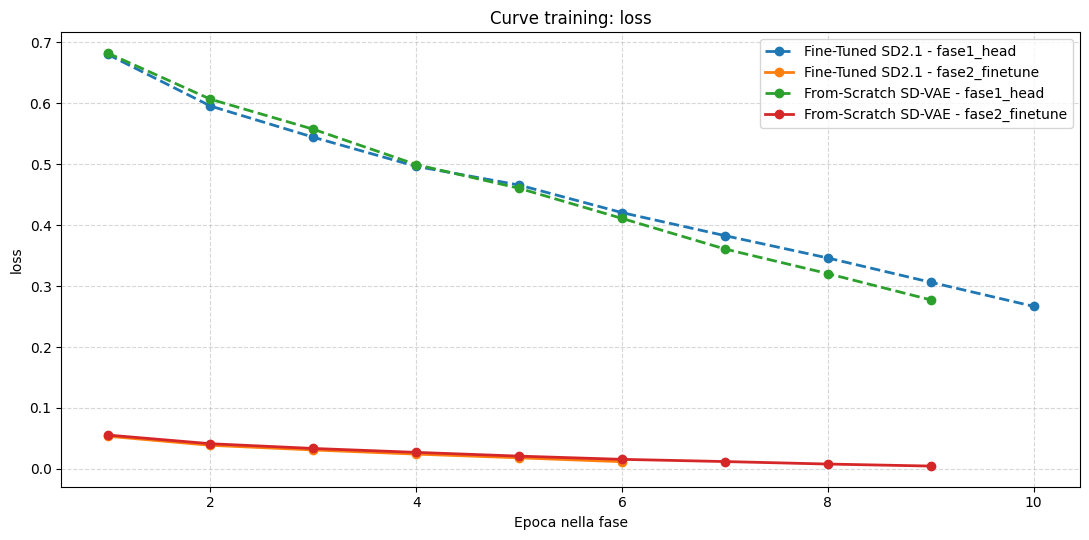

Grafico salvato in: /home/fede/Documenti/MammoDiffusion/experiments/compare_22c_fromscratch_sdvae_vs_finetuned_sd21/figures/training_loss_22c.png


In [10]:
def plot_training_metric(training_logs_df, metric_col, save_path):
    if training_logs_df.empty:
        print('Training log non disponibili.')
        return
    if metric_col not in training_logs_df.columns:
        print(f'Colonna {metric_col} non presente nei log. Colonne disponibili: {list(training_logs_df.columns)}')
        return

    fig, ax = plt.subplots(figsize=(11, 5.5))
    for (label, phase), sub in training_logs_df.groupby(['source_label', 'phase']):
        sub = sub.sort_values('phase_epoch')
        linestyle = '-' if phase == 'fase2_finetune' else '--'
        ax.plot(sub['phase_epoch'], sub[metric_col], marker='o', linewidth=2, linestyle=linestyle, label=f'{label} - {phase}')

    ax.set_title(f'Curve training: {metric_col}')
    ax.set_xlabel('Epoca nella fase')
    ax.set_ylabel(metric_col)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print('Grafico salvato in:', save_path)

if not training_logs_df.empty:
    display(training_logs_df.head())

for metric_col in ['val_auc', 'auc', 'val_loss', 'loss']:
    plot_training_metric(training_logs_df, metric_col, FIGURES_DIR / f'training_{metric_col}_22c.png')

## 10. Figure confusion matrix + ROC prodotte da 22a/22b

### From-Scratch SD-VAE

**test_confusion_roc_maxvit512.png**

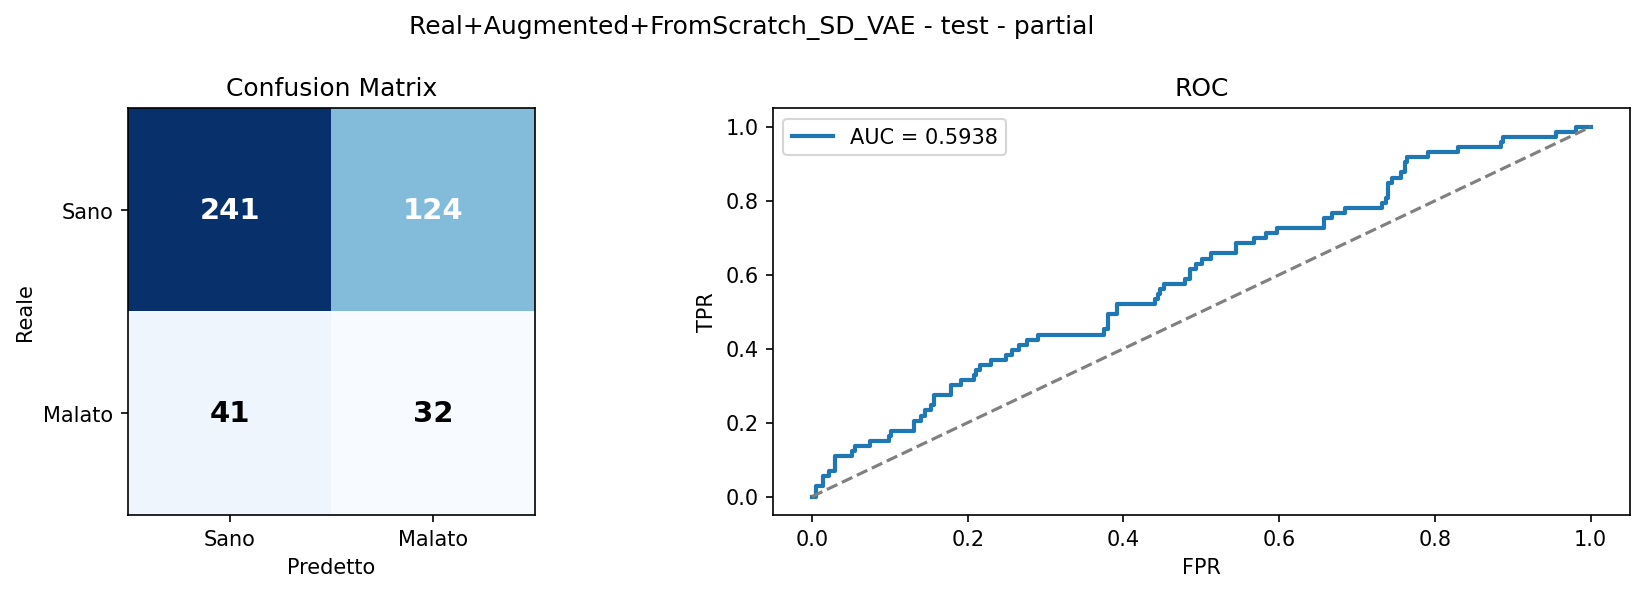

**val_confusion_roc.png**

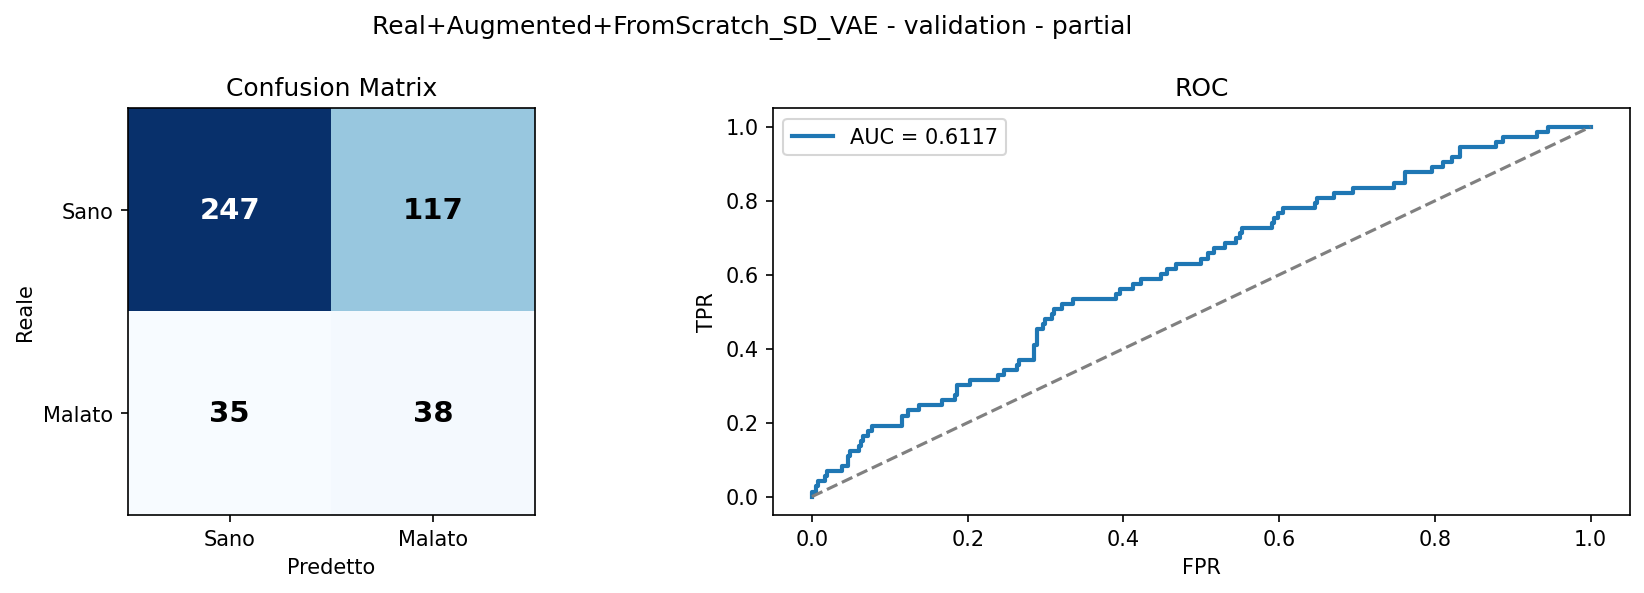

**bootstrap_maxvit512.png**

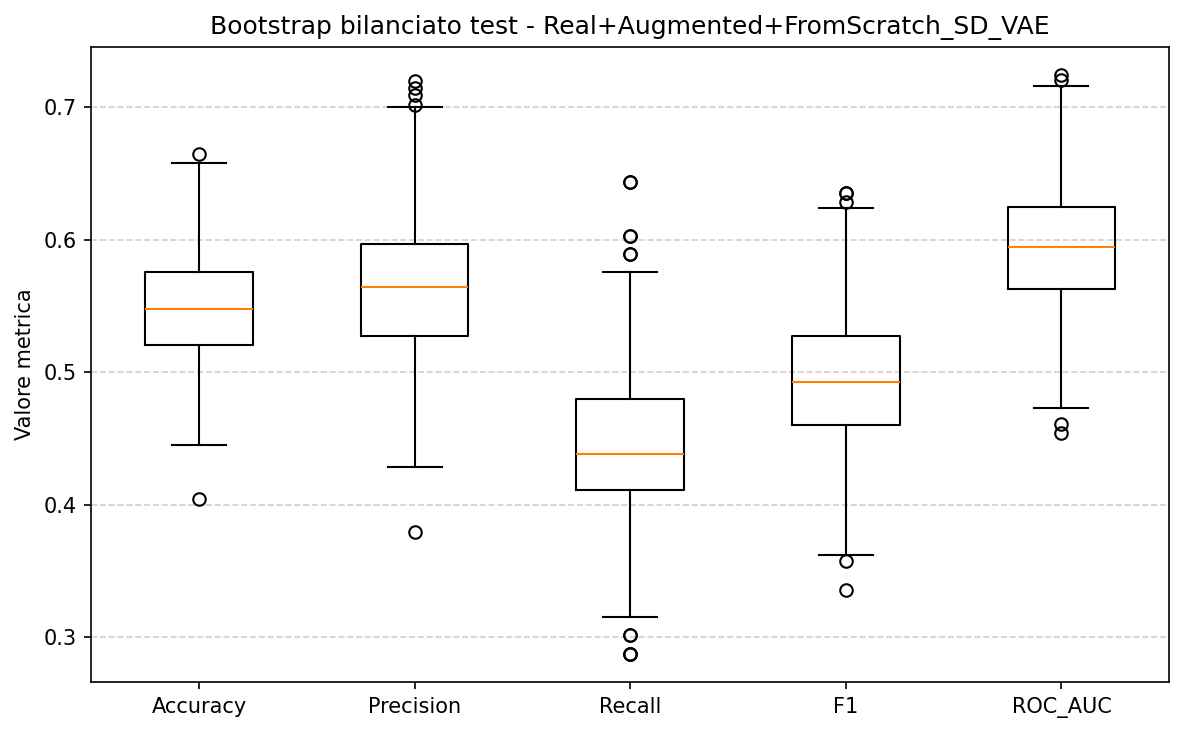

### Fine-Tuned SD2.1

**test_confusion_roc_maxvit512.png**

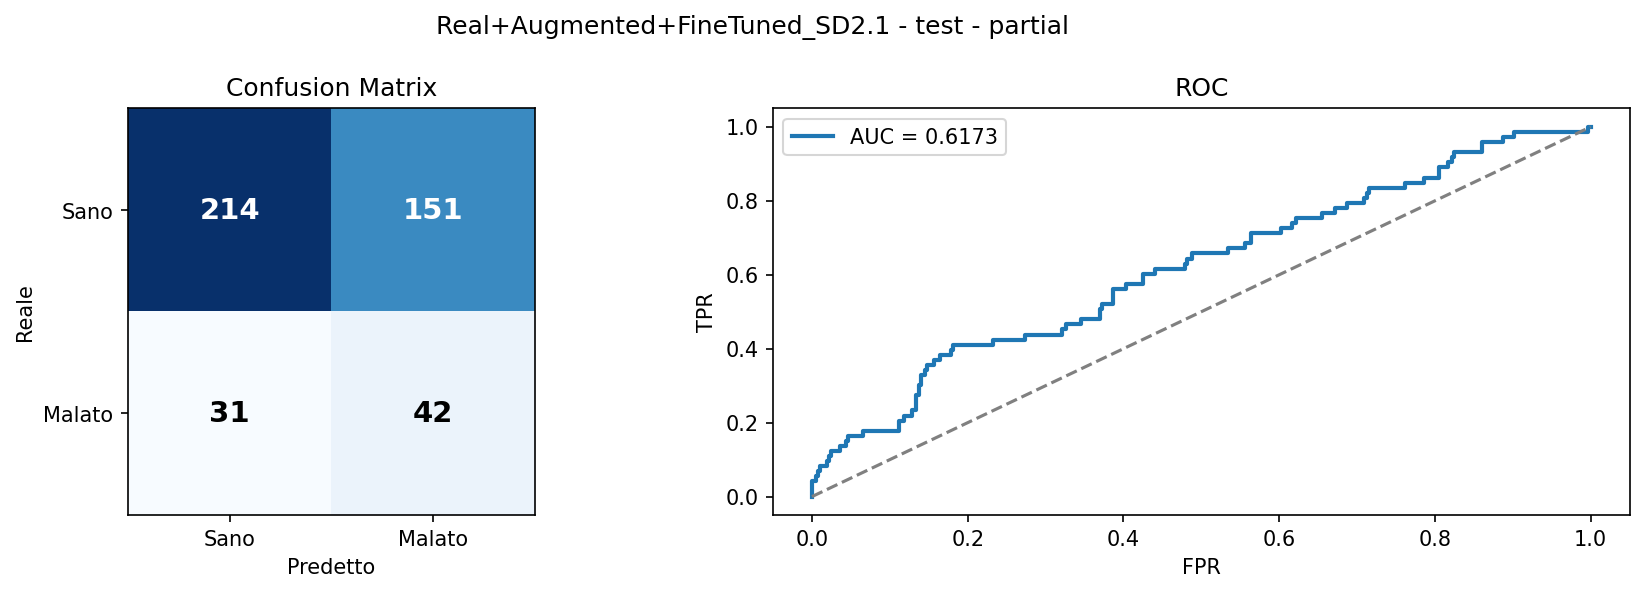

**val_confusion_roc.png**

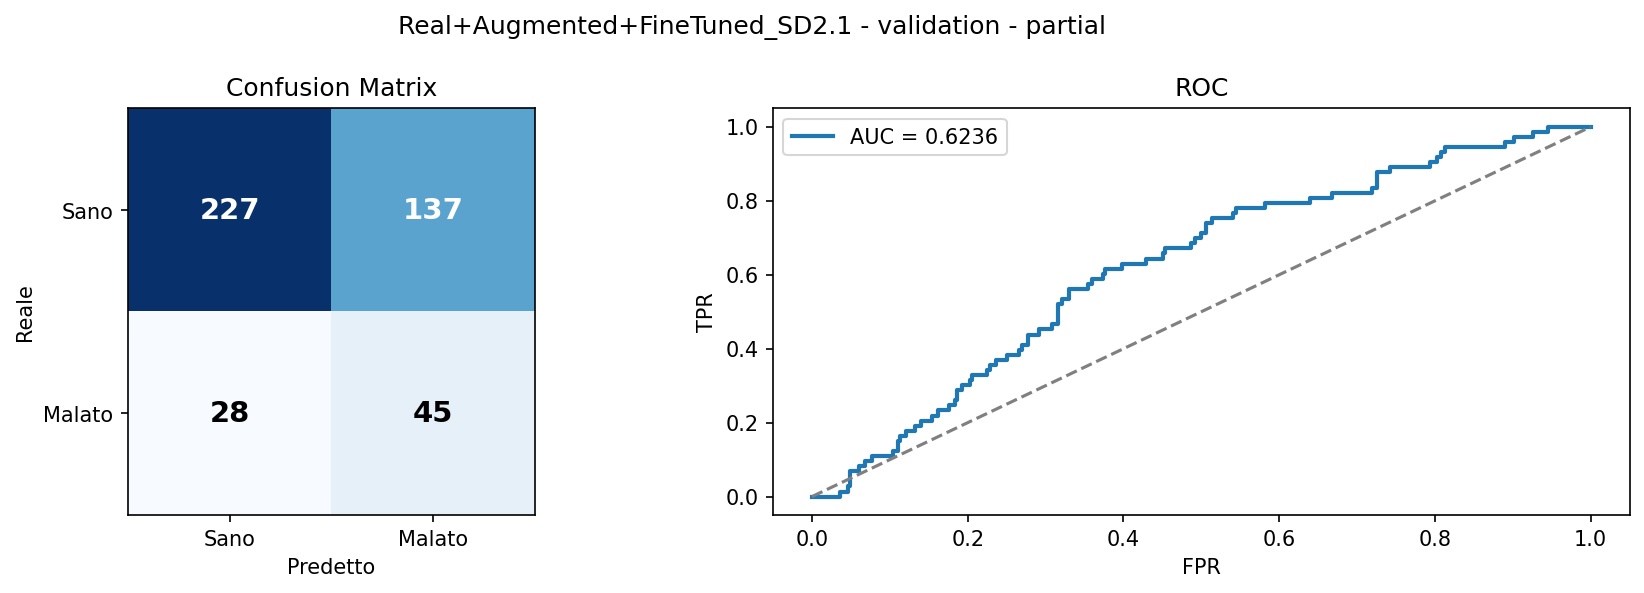

**bootstrap_maxvit512.png**

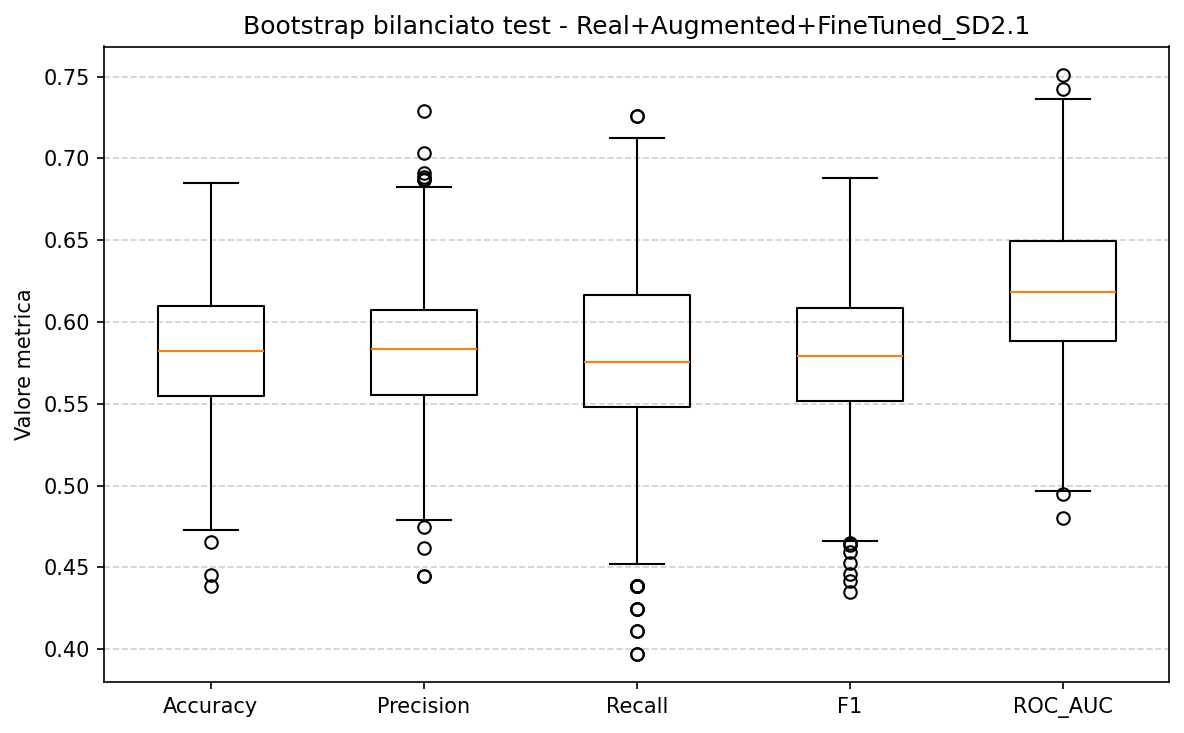

In [11]:
for experiment_key, cfg in EXPERIMENTS.items():
    exp_dir = Path(cfg['experiment_dir'])
    image_paths = [
        exp_dir / 'figures' / 'test_confusion_roc_maxvit512.png',
        exp_dir / 'figures' / 'val_confusion_roc.png',
        exp_dir / 'figures' / 'bootstrap_maxvit512.png',
    ]
    display(Markdown(f"### {cfg['label']}"))
    for image_path in image_paths:
        if image_path.exists():
            display(Markdown(f'**{image_path.name}**'))
            display(Image(filename=str(image_path)))
        else:
            print('Figura mancante:', image_path)

## 11. File prodotti dal notebook 22c

La cella seguente riepiloga i CSV/JSON/PNG generati dal confronto.

In [13]:
produced_files = []
for path in sorted(COMPARE_DIR.glob('*')):
    if path.is_file():
        produced_files.append({'file': path.name, 'path': str(path), 'size_kb': round(path.stat().st_size / 1024, 2)})
for path in sorted(FIGURES_DIR.glob('*')):
    if path.is_file():
        produced_files.append({'file': f'figures/{path.name}', 'path': str(path), 'size_kb': round(path.stat().st_size / 1024, 2)})

produced_df = pd.DataFrame(produced_files)
display(produced_df)
print('Cartella output:', COMPARE_DIR)

,file,path,size_kb
0,bootstrap_22c_long.csv,/home/fede/Documenti/MammoDiffusion/experiment...,0.85
1,bootstrap_delta_22c.csv,/home/fede/Documenti/MammoDiffusion/experiment...,0.86
2,conclusion_22c.json,/home/fede/Documenti/MammoDiffusion/experiment...,1.18
3,delta_test_22c.csv,/home/fede/Documenti/MammoDiffusion/experiment...,0.38
4,experiment_config_22c_summary.csv,/home/fede/Documenti/MammoDiffusion/experiment...,0.40
5,metrics_22c_long.csv,/home/fede/Documenti/MammoDiffusion/experiment...,1.51
6,source_counts_22c.csv,/home/fede/Documenti/MammoDiffusion/experiment...,0.48
7,summary_validation_test_22c.csv,/home/fede/Documenti/MammoDiffusion/experiment...,1.02
8,training_logs_22c_long.csv,/home/fede/Documenti/MammoDiffusion/experiment...,5.11
9,wide_comparison_22c.csv,/home/fede/Documenti/MammoDiffusion/experiment...,0.88


Cartella output: /home/fede/Documenti/MammoDiffusion/experiments/compare_22c_fromscratch_sdvae_vs_finetuned_sd21
